In [ ]:
!pip install transformers pandas torch scikit-learn
!pip install nltk spacy word2number
!python -m spacy download en_core_web_sm
!pip install -U transformers

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5568 sha256=e99f1faf9549c5a04607e18275f38005409a1bc6625ed3b8e75926fd7f561d9c
  Stored in directory: /root/.cache/pip/wheels/5b/79/fb/d25928e599c7e11fe4e00d32048cd74933f34a74c633d2aea6
Successfully built word2number
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,2.398416,0.120301,0.014472,0.120301,0.025836
2,2.411800,2.353501,0.120301,0.014472,0.120301,0.025836
3,2.357500,2.141334,0.379699,0.343139,0.379699,0.317654
4,2.055300,1.565644,0.669173,0.583204,0.669173,0.615318
5,2.055300,1.130479,0.721805,0.620946,0.721805,0.665683
6,1.423500,0.876322,0.774436,0.705081,0.774436,0.720511
7,0.987600,0.723678,0.827068,0.839572,0.827068,0.800095
8,0.734700,0.618111,0.842105,0.848463,0.842105,0.825456
9,0.620600,0.544052,0.853383,0.856085,0.853383,0.834623
10,0.620600,0.486799,0.875940,0.876893,0.875940,0.865420


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           A       0.93      0.88      0.90        32
           F       0.86      0.82      0.84        39
          FT       1.00      1.00      1.00        31
           L       0.97      0.97      0.97        31
          LF       0.82      0.94      0.88        35
          MN       0.91      1.00      0.95        30
           O       1.00      0.33      0.50         9
          PE       1.00      0.38      0.55         8
          SC       0.86      1.00      0.93        32
          SE       0.67      1.00      0.80        10
          US       0.86      0.60      0.71        10

    accuracy                           0.89       267
   macro avg       0.90      0.81      0.82       267
weighted avg       0.90      0.89      0.88       267



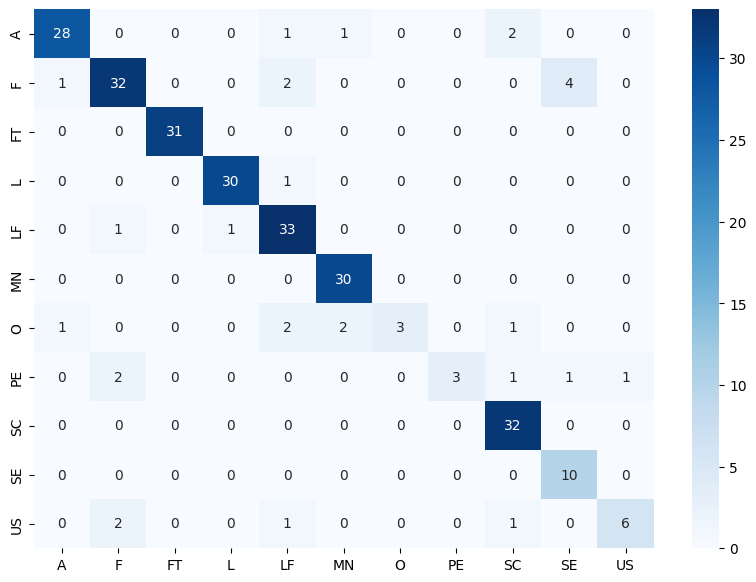

In [ ]:
# --- Imports ---
import os
import random
import re
import string
from nltk.corpus import stopwords, wordnet
import nltk
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
from transformers import (
    RobertaTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    RobertaModel,
    TrainerCallback
)
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Setup ---
os.environ["WANDB_DISABLED"] = "true"
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))

# --- Text Processing ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in stop_words and len(word) > 3]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def phrase_insertion(text, n=1):
    phrases = ["the system shall", "must be able to", "should ensure that"]
    words = text.split()
    for _ in range(n):
        add_phrase = random.choice(phrases)
        random_idx = random.randint(0, len(words)-1)
        words.insert(random_idx, add_phrase)
    return ' '.join(words)

def text_simplification(text):
    text = re.sub(r'\bthe system shall\b', '', text)
    text = re.sub(r'\bmust be able to\b', '', text)
    text = re.sub(r'\bshould ensure that\b', '', text)
    return text.strip()

def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) == 1:
        return text
    remaining = [word for word in words if random.random() > p]
    return ' '.join(remaining) if remaining else random.choice(words)

def random_swap(text, n=1):
    words = text.split()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# --- Data Loading ---
DATA_URL = 'https://raw.githubusercontent.com/egbertbritannia-cpu/rbl-requirements-classification/main/data/exp/promise_exp.csv'
data_path = DATA_URL

df = pd.read_csv(data_path)
print(f"Loaded PROMISE expanded dataset from: {data_path}")
df['cleaned_text'] = df['RequirementText'].apply(clean_text)
df = df[df['class'].map(df['class'].value_counts()) > 1]

# --- Augmentation ---
augmentation_targets = {'FT':200,'L':200,'MN':200,'A':200,'CS':200,'LF':200,'SC':200,'PO':200}
augmented = []

for cls, min_required in augmentation_targets.items():
    class_df = df[df['class'] == cls]
    needed = max(0, min_required - len(class_df))
    if len(class_df) == 0 or needed == 0:
        continue
    multiplier = needed // len(class_df) + 1
    for _, row in class_df.iterrows():
        for _ in range(multiplier):
            text = row['cleaned_text']
            aug_text = synonym_replacement(text, 1)
            aug_text = phrase_insertion(aug_text, 1)
            aug_text = text_simplification(aug_text)
            aug_text = random_swap(aug_text, 1)
            aug_text = random_deletion(aug_text, p=0.1)
            augmented.append({
                'RequirementText': row['RequirementText'],
                'cleaned_text': aug_text,
                'class': cls
            })

df_aug = pd.DataFrame(augmented)
df_combined = pd.concat([df, df_aug], ignore_index=True)

# --- Label Encoding & Split ---
texts = df_combined['cleaned_text'].tolist()
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df_combined['class'])

train_texts, val_test_texts, train_labels, val_test_labels = train_test_split(
    texts, labels, test_size=0.3, stratify=labels, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    val_test_texts, val_test_labels, test_size=0.5,
    stratify=val_test_labels, random_state=42
)

# --- Tokenization (RoBERTa ONLY) ---
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(tokenizer, texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=128)

train_enc = tokenize(roberta_tokenizer, train_texts)
val_enc   = tokenize(roberta_tokenizer, val_texts)
test_enc  = tokenize(roberta_tokenizer, test_texts)

# --- Dataset ---
class RobertaOnlyDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.enc['input_ids'][idx]),
            'attention_mask': torch.tensor(self.enc['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

train_dataset = RobertaOnlyDataset(train_enc, train_labels)
val_dataset   = RobertaOnlyDataset(val_enc, val_labels)
test_dataset  = RobertaOnlyDataset(test_enc, test_labels)

# --- Model ---
class RobertaOnlyClassifier(torch.nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.dropout = torch.nn.Dropout(0.5)
        self.classifier = torch.nn.Linear(768, num_labels, bias=False)

        for name, param in self.roberta.named_parameters():
            if name.startswith("encoder.layer.") and int(name.split(".")[2]) < 8:
                param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels=None):
        output = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).pooler_output

        logits = self.classifier(self.dropout(output))
        loss = torch.nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}

# --- Metrics ---
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

# --- Accuracy Callback ---
class AccuracyPlotCallback(TrainerCallback):
    def __init__(self):
        self.train_accuracies = []
        self.val_accuracies = []
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, args, state, control, **kwargs):
        train_metrics = trainer.evaluate(train_dataset)
        val_metrics = trainer.evaluate(val_dataset)
        self.train_accuracies.append(train_metrics["eval_accuracy"])
        self.val_accuracies.append(val_metrics["eval_accuracy"])
        self.train_losses.append(train_metrics["eval_loss"])
        self.val_losses.append(val_metrics["eval_loss"])

accuracy_callback = AccuracyPlotCallback()

# --- Training ---
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.02,
    learning_rate=1e-5,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    gradient_accumulation_steps=2,
    fp16=True,
    report_to="none",
)

model = RobertaOnlyClassifier(num_labels=len(label_encoder.classes_))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), accuracy_callback]
)

trainer.train()

# --- Evaluation ---
test_results = trainer.predict(test_dataset)
test_preds = test_results.predictions.argmax(-1)

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_
))

# --- Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.show()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.503900,2.486211,0.085960,0.017910,0.085960,0.018736
2,2.456600,2.420403,0.191977,0.036855,0.191977,0.061839
3,2.371400,2.202339,0.191977,0.036855,0.191977,0.061839
4,2.016600,1.553970,0.584527,0.550005,0.584527,0.531296
5,1.494800,1.148660,0.719198,0.657167,0.719198,0.672219
6,1.162000,0.937871,0.759312,0.724228,0.759312,0.721489
7,0.952100,0.797302,0.770774,0.759089,0.770774,0.734906
8,0.811500,0.701078,0.796562,0.777478,0.796562,0.769304
9,0.674200,0.628463,0.816619,0.790678,0.816619,0.789572
10,0.600600,0.574993,0.833811,0.845975,0.833811,0.817703


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           A       0.93      0.81      0.87        32
           F       0.91      0.89      0.90        66
          FT       0.94      1.00      0.97        33
           L       0.97      1.00      0.98        32
          LF       0.88      0.95      0.91        37
          MN       0.91      0.97      0.94        33
           O       0.71      0.42      0.53        12
          PE       0.78      0.70      0.74        10
          PO       0.91      1.00      0.95        30
          SC       0.94      0.97      0.96        33
          SE       0.80      0.84      0.82        19
          US       0.80      0.67      0.73        12

    accuracy                           0.90       349
   macro avg       0.87      0.85      0.86       349
weighted avg       0.90      0.90      0.90       349



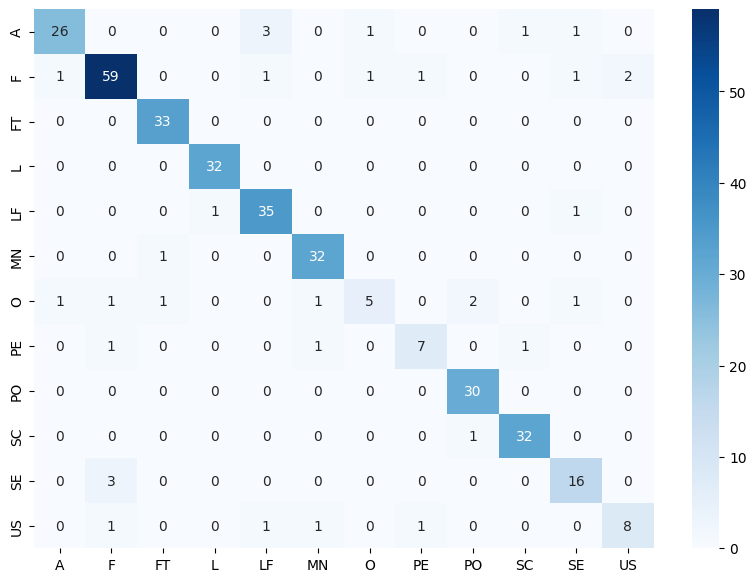

In [ ]:
# --- Imports ---
import os
import random
import re
import string
from nltk.corpus import stopwords, wordnet
import nltk
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
from transformers import (
    RobertaTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    RobertaModel,
    TrainerCallback
)
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Setup ---
os.environ["WANDB_DISABLED"] = "true"
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))

# --- Text Processing ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            if synonym != word:
                synonyms.add(synonym)
    return list(synonyms)

def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in stop_words and len(word) > 3]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) >= 1:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def phrase_insertion(text, n=1):
    phrases = ["the system shall", "must be able to", "should ensure that"]
    words = text.split()
    for _ in range(n):
        add_phrase = random.choice(phrases)
        random_idx = random.randint(0, len(words)-1)
        words.insert(random_idx, add_phrase)
    return ' '.join(words)

def text_simplification(text):
    text = re.sub(r'\bthe system shall\b', '', text)
    text = re.sub(r'\bmust be able to\b', '', text)
    text = re.sub(r'\bshould ensure that\b', '', text)
    return text.strip()

def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) == 1:
        return text
    remaining = [word for word in words if random.random() > p]
    return ' '.join(remaining) if remaining else random.choice(words)

def random_swap(text, n=1):
    words = text.split()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# --- Data Loading ---
DATA_URL = 'https://raw.githubusercontent.com/egbertbritannia-cpu/rbl-requirements-classification/main/data/exp/promise_exp.csv'
data_path = DATA_URL

df = pd.read_csv(data_path)
print(f"Loaded PROMISE expanded dataset from: {data_path}")
df['cleaned_text'] = df['RequirementText'].apply(clean_text)
df = df[df['class'].map(df['class'].value_counts()) > 1]

# --- Augmentation ---
augmentation_targets = {'FT':200,'L':200,'MN':200,'A':200,'CS':200,'LF':200,'SC':200,'PO':200}
augmented = []

for cls, min_required in augmentation_targets.items():
    class_df = df[df['class'] == cls]
    needed = max(0, min_required - len(class_df))
    if len(class_df) == 0 or needed == 0:
        continue
    multiplier = needed // len(class_df) + 1
    for _, row in class_df.iterrows():
        for _ in range(multiplier):
            text = row['cleaned_text']
            aug_text = synonym_replacement(text, 1)
            aug_text = phrase_insertion(aug_text, 1)
            aug_text = text_simplification(aug_text)
            aug_text = random_swap(aug_text, 1)
            aug_text = random_deletion(aug_text, p=0.1)
            augmented.append({
                'RequirementText': row['RequirementText'],
                'cleaned_text': aug_text,
                'class': cls
            })

df_aug = pd.DataFrame(augmented)
df_combined = pd.concat([df, df_aug], ignore_index=True)

# --- Label Encoding & Split ---
texts = df_combined['cleaned_text'].tolist()
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df_combined['class'])

train_texts, val_test_texts, train_labels, val_test_labels = train_test_split(
    texts, labels, test_size=0.3, stratify=labels, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    val_test_texts, val_test_labels, test_size=0.5,
    stratify=val_test_labels, random_state=42
)

# --- Tokenization (RoBERTa ONLY) ---
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(tokenizer, texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=128)

train_enc = tokenize(roberta_tokenizer, train_texts)
val_enc   = tokenize(roberta_tokenizer, val_texts)
test_enc  = tokenize(roberta_tokenizer, test_texts)

# --- Dataset ---
class RobertaOnlyDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.enc['input_ids'][idx]),
            'attention_mask': torch.tensor(self.enc['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

train_dataset = RobertaOnlyDataset(train_enc, train_labels)
val_dataset   = RobertaOnlyDataset(val_enc, val_labels)
test_dataset  = RobertaOnlyDataset(test_enc, test_labels)

# --- Model ---
class RobertaOnlyClassifier(torch.nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.dropout = torch.nn.Dropout(0.5)
        self.classifier = torch.nn.Linear(768, num_labels, bias=False)

        for name, param in self.roberta.named_parameters():
            if name.startswith("encoder.layer.") and int(name.split(".")[2]) < 8:
                param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels=None):
        output = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).pooler_output

        logits = self.classifier(self.dropout(output))
        loss = torch.nn.CrossEntropyLoss()(logits, labels) if labels is not None else None
        return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}

# --- Metrics ---
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

# --- Accuracy Callback ---
class AccuracyPlotCallback(TrainerCallback):
    def __init__(self):
        self.train_accuracies = []
        self.val_accuracies = []
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, args, state, control, **kwargs):
        train_metrics = trainer.evaluate(train_dataset)
        val_metrics = trainer.evaluate(val_dataset)
        self.train_accuracies.append(train_metrics["eval_accuracy"])
        self.val_accuracies.append(val_metrics["eval_accuracy"])
        self.train_losses.append(train_metrics["eval_loss"])
        self.val_losses.append(val_metrics["eval_loss"])

accuracy_callback = AccuracyPlotCallback()

# --- Training ---
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.02,
    learning_rate=1e-5,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    gradient_accumulation_steps=2,
    fp16=True,
    report_to="none",
)

model = RobertaOnlyClassifier(num_labels=len(label_encoder.classes_))

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2), accuracy_callback]
)

trainer.train()

# --- Evaluation ---
test_results = trainer.predict(test_dataset)
test_preds = test_results.predictions.argmax(-1)

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_
))

# --- Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.show()
